Imports

In [18]:
import numpy as np
import pandas as pd

Read csv file

In [19]:
ott = pd.read_csv('ott_merge.csv')
ott.head()

,user_id,age_group,city_tier,subscription_plan,new_subscription_plan,platform,total_watch_time,days_since_last_active,days_in_new_plan,days_before_new_plan,subscription_plan_status
0,UIDJS0000751588f,18-24,Tier 1,Premium,NaN,Jotstar,40127,204.0,0.0,0.0,Retained
1,UIDJS000093eeb86,18-24,Tier 1,Free,NaN,Jotstar,3868,52.0,0.0,0.0,Retained
2,UIDJS00010d7fa1e,25-34,Tier 1,Free,NaN,Jotstar,9913,145.0,0.0,0.0,Retained
3,UIDJS00013411a85,35-44,Tier 2,VIP,NaN,Jotstar,21797,214.0,0.0,0.0,Retained
4,UIDJS0003a3f54cf,35-44,Tier 1,Premium,NaN,Jotstar,11531,102.0,0.0,0.0,Retained


In [20]:
ott['subscription_plan_status'].unique()

array(['Retained', 'Churned', 'Upgrade', 'Downgrade'], dtype=object)

Convert Categorical columns values into numeric values 

In [21]:
# mapping all categorical text values to numerical values
age_map = {'18-24':0,'25-34':1,'35-44':2,'45+':3}
city_tier_map = {'Tier 1':1,'Tier 2':2,'Tier 3':3}
platform_map = {'Jotstar':0,'Liocinema':1}
subscription_plan_map = {'Free':0,'Basic':1,'Premium':2,'VIP':3, np.nan : -1}
target_col = {'Retained':0, 'Downgrade':1,'Upgrade':2, 'Churned':3 }

ott['age_group'] = ott['age_group'].map(age_map)
ott['city_tier'] = ott['city_tier'].map(city_tier_map)
ott['platform'] = ott['platform'].map(platform_map)
ott['subscription_plan']  = ott['subscription_plan'].map(subscription_plan_map)
ott['new_subscription_plan'] = ott['new_subscription_plan'].map(subscription_plan_map)
ott['subscription_plan_status'] = ott['subscription_plan_status'].map(target_col)

In [22]:
ott.groupby('subscription_plan_status')['user_id'].count().reset_index()

,subscription_plan_status,user_id
0,0,107005
1,1,26054
2,2,6050
3,3,88957


In [23]:
ott.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228066 entries, 0 to 228065
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   228066 non-null  object 
 1   age_group                 228066 non-null  int64  
 2   city_tier                 228066 non-null  int64  
 3   subscription_plan         228066 non-null  int64  
 4   new_subscription_plan     228066 non-null  int64  
 5   platform                  228066 non-null  int64  
 6   total_watch_time          228066 non-null  int64  
 7   days_since_last_active    228066 non-null  float64
 8   days_in_new_plan          228066 non-null  float64
 9   days_before_new_plan      228066 non-null  float64
 10  subscription_plan_status  228066 non-null  int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 19.1+ MB


Fix skewed columns with log transformation

In [24]:
# log1p is safe — handles 0 values (log of 0 is undefined, log1p(0) = 0)
ott['total_watch_time']     = np.log1p(ott['total_watch_time'])
ott['days_in_new_plan']     = np.log1p(ott['days_in_new_plan'])
ott['days_before_new_plan'] = np.log1p(ott['days_before_new_plan'])

Find correlation of columns

In [25]:
ott.select_dtypes(include=['int64', 'float64']).corr()

,age_group,city_tier,subscription_plan,new_subscription_plan,platform,total_watch_time,days_since_last_active,days_in_new_plan,days_before_new_plan,subscription_plan_status
age_group,1.000000,-0.045721,0.083215,0.082675,-0.150828,0.036974,0.082403,0.036830,0.041833,-0.083510
city_tier,-0.045721,1.000000,-0.331142,-0.134372,0.316865,-0.407279,-0.187443,-0.112544,-0.117229,0.189218
subscription_plan,0.083215,-0.331142,1.000000,0.228674,-0.528220,0.601174,0.310023,0.283357,0.281537,-0.285091
new_subscription_plan,0.082675,-0.134372,0.228674,1.000000,-0.126793,0.324079,0.314663,0.836591,0.857450,-0.001405
platform,-0.150828,0.316865,-0.528220,-0.126793,1.000000,-0.559021,-0.363539,-0.034117,-0.036604,0.243778
total_watch_time,0.036974,-0.407279,0.601174,0.324079,-0.559021,1.000000,0.830703,0.349938,0.335070,-0.569554
days_since_last_active,0.082403,-0.187443,0.310023,0.314663,-0.363539,0.830703,1.000000,0.392796,0.356125,-0.393230
days_in_new_plan,0.036830,-0.112544,0.283357,0.836591,-0.034117,0.349938,0.392796,1.000000,0.951688,-0.044584
days_before_new_plan,0.041833,-0.117229,0.281537,0.857450,-0.036604,0.335070,0.356125,0.951688,1.000000,-0.038855
subscription_plan_status,-0.083510,0.189218,-0.285091,-0.001405,0.243778,-0.569554,-0.393230,-0.044584,-0.038855,1.000000


In [26]:
print("Shape:", ott.shape)
print("\nMissing values:\n", ott.isnull().sum())
print("\nDtypes:\n", ott.dtypes)
print("\nTarget distribution:")
print(ott['subscription_plan_status'].value_counts())

Shape: (228066, 11)

Missing values:
 user_id                     0
age_group                   0
city_tier                   0
subscription_plan           0
new_subscription_plan       0
platform                    0
total_watch_time            0
days_since_last_active      0
days_in_new_plan            0
days_before_new_plan        0
subscription_plan_status    0
dtype: int64

Dtypes:
 user_id                      object
age_group                     int64
city_tier                     int64
subscription_plan             int64
new_subscription_plan         int64
platform                      int64
total_watch_time            float64
days_since_last_active      float64
days_in_new_plan            float64
days_before_new_plan        float64
subscription_plan_status      int64
dtype: object

Target distribution:
subscription_plan_status
0    107005
3     88957
1     26054
2      6050
Name: count, dtype: int64


Train and Test split

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

user_ids = ott['user_id']

X = ott.drop(columns=['user_id', 'subscription_plan_status'])

y = ott['subscription_plan_status']

print(f' X shape: {X.shape}   y Shape:{y.shape}  \nFeatures: {X.columns.tolist()}')

 X shape: (228066, 9)   y Shape:(228066,)  
Features: ['age_group', 'city_tier', 'subscription_plan', 'new_subscription_plan', 'platform', 'total_watch_time', 'days_since_last_active', 'days_in_new_plan', 'days_before_new_plan']


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y # to keep class % same in both splits
)
print(f"X_train: {X_train.shape} \nX_test:{X_test.shape}")

X_train: (182452, 9) 
X_test:(45614, 9)


Decision Tree Classifier Model

In [29]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)


print("Decision Tree Accuracy:", round(dt_acc * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, dt_preds,
      target_names=['Retained', 'Downgrade', 'Upgrade', 'Churned']))

Decision Tree Accuracy: 81.98 %

Classification Report:
              precision    recall  f1-score   support

    Retained       0.85      0.75      0.80     21401
   Downgrade       1.00      1.00      1.00      5211
     Upgrade       1.00      1.00      1.00      1210
     Churned       0.74      0.84      0.78     17792

    accuracy                           0.82     45614
   macro avg       0.90      0.90      0.90     45614
weighted avg       0.83      0.82      0.82     45614



Random Forest Model

In [30]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds)

print("Random Forest Accuracy:", round(rf_acc * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds,
      target_names=['Retained', 'Downgrade', 'Upgrade', 'Churned']))

Random Forest Accuracy: 87.56 %

Classification Report:
              precision    recall  f1-score   support

    Retained       0.86      0.88      0.87     21401
   Downgrade       1.00      1.00      1.00      5211
     Upgrade       1.00      1.00      1.00      1210
     Churned       0.85      0.82      0.84     17792

    accuracy                           0.88     45614
   macro avg       0.93      0.93      0.93     45614
weighted avg       0.88      0.88      0.88     45614



Confusion Matrix

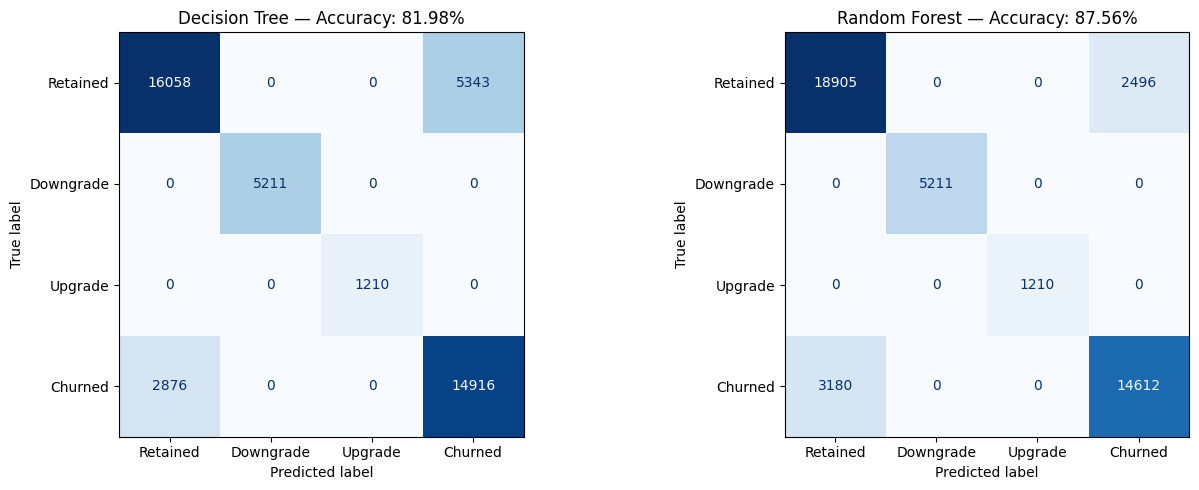

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name in zip(axes,
                            [dt_preds, rf_preds],
                            ['Decision Tree', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm,
           display_labels=['Retained', 'Downgrade', 'Upgrade', 'Churned'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} — Accuracy: {accuracy_score(y_test, preds)*100:.2f}%')
    ax.grid(False)

plt.tight_layout()
plt.show()

Feature Importance Mapping

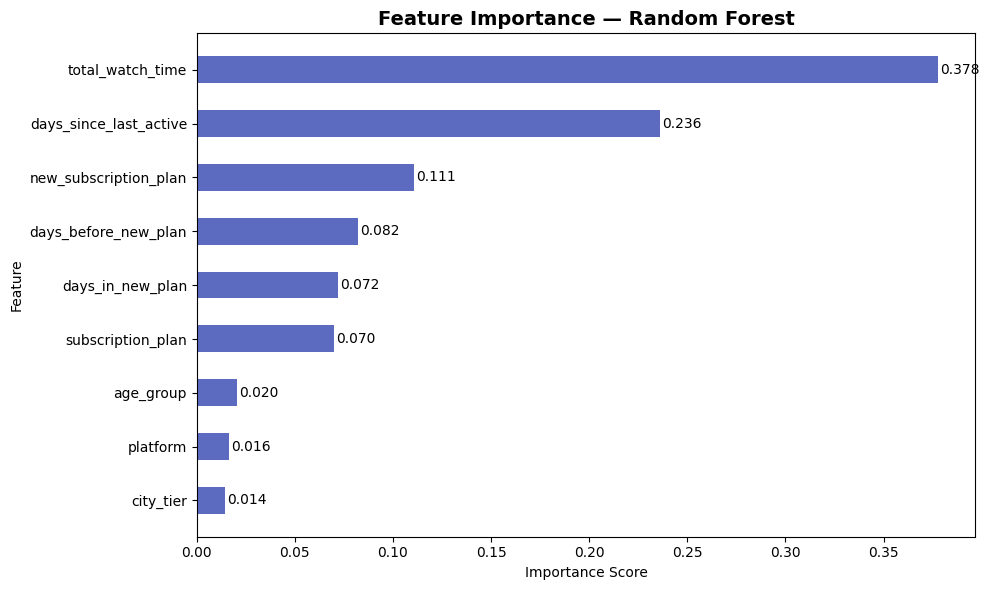

               feature  importance
      total_watch_time    0.377963
days_since_last_active    0.236180
 new_subscription_plan    0.110612
  days_before_new_plan    0.082046
      days_in_new_plan    0.072072
     subscription_plan    0.069987
             age_group    0.020478
              platform    0.016357
             city_tier    0.014304


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature'   : X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    feature_importance['feature'],
    feature_importance['importance'],
    color='#5C6BC0', height=0.5
)

# Add value labels on bars
for bar, val in zip(bars, feature_importance['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

# Print exact numbers
print(feature_importance.sort_values('importance', ascending=False).to_string(index=False))
